In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
df = sns.load_dataset("titanic")

In [17]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [19]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [20]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [23]:
df= df.drop("deck",axis=1)

In [24]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [ ]:
df.isnull().sum()
cols=["who","adult_male","sibsp","parch"]
df=df.drop(cols,axis=1)
df=df.drop("embark_town",axis=1)

In [31]:
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
df[["age"]] = imp_median.fit_transform(df[["age"]])

In [33]:
x = df.drop("survived",axis=1)
y = df["survived"]

In [38]:
x.sample(10)


,pclass,sex,age,fare,embarked,class,alone
439,2,male,31.0,10.5000,S,Second,True
381,3,female,1.0,15.7417,C,Third,False
804,3,male,27.0,6.9750,S,Third,True
795,2,male,39.0,13.0000,S,Second,True
322,2,female,30.0,12.3500,Q,Second,True
431,3,female,28.0,16.1000,S,Third,False
30,1,male,40.0,27.7208,C,First,True
639,3,male,28.0,16.1000,S,Third,False
546,2,female,19.0,26.0000,S,Second,False
686,3,male,14.0,39.6875,S,Third,False


In [39]:
from sklearn.preprocessing import LabelEncoder

lable_enc = LabelEncoder()
x["sex"] = lable_enc.fit_transform(x["sex"])
x["embarked"] = lable_enc.fit_transform(x["embarked"])
x["class"] = lable_enc.fit_transform(x["class"])
x["alone"] = lable_enc.fit_transform(x["alone"])

In [41]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test= train_test_split(
    x,y,
    random_state=42
)

In [42]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(x_train,y_train)
y_pred = model.predict(x_test)

print("accuracy : ",model.score(x_test,y_test))


accuracy :  0.757847533632287


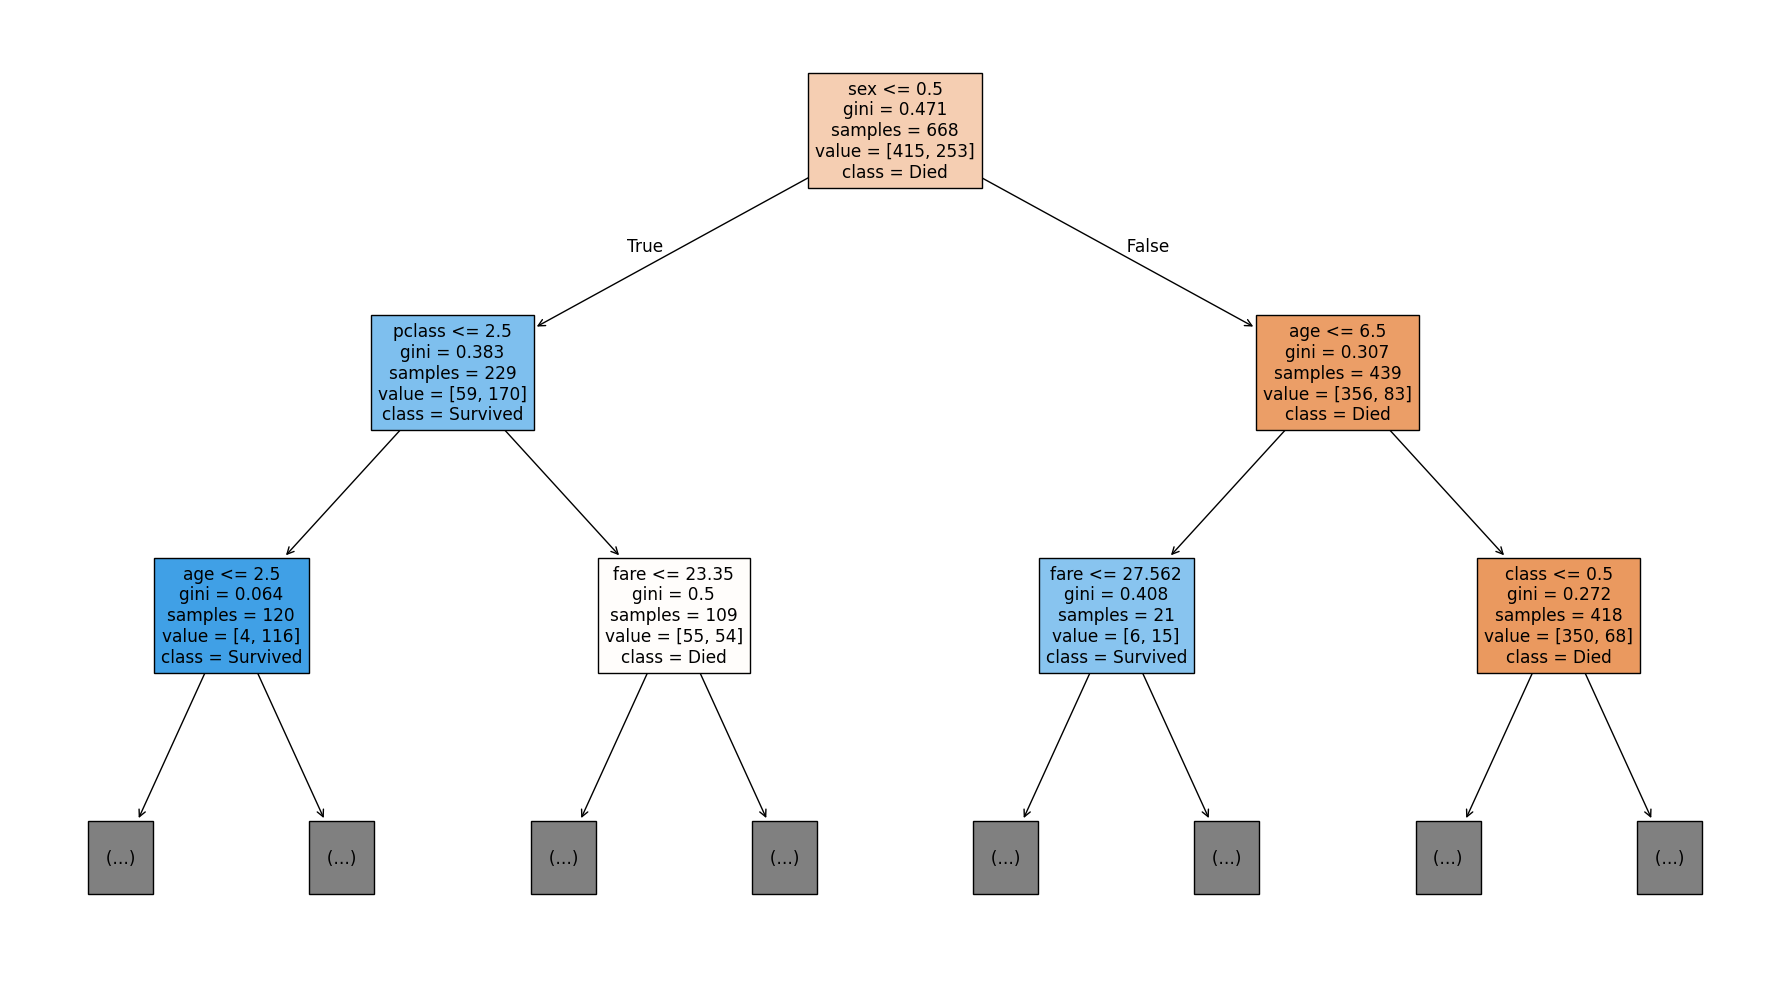

In [47]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=2
)

plt.tight_layout()
plt.show()

In [49]:
accuracy = []
max_width = [2,3,4,5,6,7,8,9,10]

for max_width in max_width:
    pre_model = DecisionTreeClassifier(max_depth=max_width)
    pre_model.fit(x_train,y_train)
    acc = pre_model.score(x_test,y_test)
    print(f"model :{max_width}, accuracy : {acc}")
   

model :2, accuracy : 0.7757847533632287
model :3, accuracy : 0.8026905829596412
model :4, accuracy : 0.8116591928251121
model :5, accuracy : 0.8071748878923767
model :6, accuracy : 0.7668161434977578
model :7, accuracy : 0.8161434977578476
model :8, accuracy : 0.7668161434977578
model :9, accuracy : 0.7892376681614349
model :10, accuracy : 0.7668161434977578


In [52]:
from sklearn.tree import DecisionTreeClassifier

split1 = [3,6,9,12,16,22,28,34,38]

best_acc = 0
best_split = None

for split in split1:
    pre_model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    pre_model.fit(x_train, y_train)

    acc = pre_model.score(x_test, y_test)

    if acc > best_acc:
        best_acc = acc
        best_split = split

print(f"Best min_samples_split: {best_split}, Accuracy: {best_acc}")

Best min_samples_split: 3, Accuracy: 0.8116591928251121
